<a href="https://colab.research.google.com/github/erdem-durmaz/AI-Projects/blob/main/WORKFLOW_FIRST_LANGGRAPH_AGENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Optional: Colab Drive mount (persistent DB için açabilirsin)
from google.colab import drive
drive.mount('/content/drive')
requirements_path = "/content/drive/MyDrive/requirements.txt"
!pip install -r {requirements_path}
!pip install -U ddgs

In [ ]:
# =========================
# WORKFLOW-FIRST LANGGRAPH AGENT
# =========================

import os
import re
import uuid
import sqlite3
from datetime import datetime
from typing import TypedDict, List, Literal, Dict, Any
from urllib.parse import quote

import httpx
from google.colab import userdata

from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage,
    BaseMessage,
)
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_groq import ChatGroq

# =========================
# CONFIG
# =========================

# Colab local:
DB_PATH = "chat_memory.db"

# Drive persistent istersen bunu aç:
# DB_PATH = "/content/drive/MyDrive/chat_memory.db"

MAX_HISTORY = 12

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

# =========================
# DB SETUP
# =========================

conn = sqlite3.connect(DB_PATH, check_same_thread=False)
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS messages (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    session_id TEXT NOT NULL,
    role TEXT NOT NULL,
    content TEXT NOT NULL,
    message_type TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")
conn.commit()


def save_message(session_id: str, role: str, content: str, message_type: str = None):
    cursor.execute("""
        INSERT INTO messages (session_id, role, content, message_type)
        VALUES (?, ?, ?, ?)
    """, (session_id, role, content, message_type))
    conn.commit()


def load_messages(session_id: str, limit: int = 12) -> List[BaseMessage]:
    cursor.execute("""
        SELECT role, content
        FROM messages
        WHERE session_id = ?
        ORDER BY id DESC
        LIMIT ?
    """, (session_id, limit))

    rows = cursor.fetchall()
    rows.reverse()

    history = []
    for role, content in rows:
        if role == "user":
            history.append(HumanMessage(content=content))
        elif role == "assistant":
            history.append(AIMessage(content=content))
    return history


def list_sessions():
    cursor.execute("""
        SELECT session_id, MIN(created_at), MAX(created_at), COUNT(*)
        FROM messages
        GROUP BY session_id
        ORDER BY MAX(created_at) DESC
    """)
    return cursor.fetchall()


def generate_session_id() -> str:
    return f"chat_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:6]}"


# =========================
# TOOLS
# =========================

search_tool = DuckDuckGoSearchRun()

@tool
def get_weather(city: str) -> str:
    """Get current weather for a city, use °C metric."""
    try:
        city_encoded = quote(city)
        resp = httpx.get(f"https://wttr.in/{city_encoded}?format=3", timeout=5)
        resp.raise_for_status()
        return f"[CURRENT_WEATHER] {resp.text}"
    except Exception:
        return "[CURRENT_WEATHER_ERROR] Güncel hava durumu verisi şu an alınamadı."

@tool
def get_exchange_rate(currency: str = "USD") -> str:
    """Get current exchange rate against Turkish Lira (TRY). currency: USD, EUR, GBP gibi."""
    try:
        currency = currency.upper().strip()
        resp = httpx.get(f"https://open.er-api.com/v6/latest/{currency}", timeout=5)
        resp.raise_for_status()
        data = resp.json()

        if data.get("result") == "success" and "TRY" in data.get("rates", {}):
            rate = data["rates"]["TRY"]
            updated = data.get("time_last_update_utc", "bilinmiyor")
            return f"[CURRENT_EXCHANGE] 1 {currency} = {rate:.4f} TRY (güncelleme: {updated})"

        return "[CURRENT_EXCHANGE_ERROR] Kur bilgisi şu an alınamadı."
    except Exception:
        return "[CURRENT_EXCHANGE_ERROR] Kur bilgisi şu an alınamadı."

@tool
def web_search(query: str) -> str:
    """Search the web for current events, recent news, or live data."""
    try:
        result = search_tool.run(query)
        return f"[WEB_SEARCH_RESULT] {result}"
    except Exception:
        return "[WEB_SEARCH_ERROR] Güncel web arama sonucu şu an alınamadı."


# =========================
# MODELS
# =========================

base_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.2
)

GENERAL_PROMPT = SystemMessage(content="""
You are a helpful assistant.

KURALLAR:
- Kısa, net ve doğal cevap ver.
- Gereksiz giriş ve kapanış yapma.
- Kullanıcının diliyle cevap ver.
- Emin değilsen kısa şekilde belirt.
""")

ANSWER_PROMPT = SystemMessage(content="""
You are a helpful assistant.

FINAL CEVAP KURALLARI:
- Sadece final kullanıcı cevabını yaz.
- Kısa, net ve doğal ol.
- Tool sonucu dışına çıkma.
- Tool sonucunda olmayan bilgi ekleme.
- Özellikle zaman bilgisi (yarın, haftaya, bugün) uydurma.
- Eğer tool sonucu CURRENT veri ise cevabı CURRENT olarak yaz.
- Eğer kullanıcı future (yarın, haftaya) sormuş ama tool forecast desteklemiyorsa bunu kısa şekilde belirt.
- Cevabında tool, arama süreci, sistem prompt veya iç işleyişten bahsetme.
- Kullanıcının diliyle cevap ver.
""")


# =========================
# STATE
# =========================

class AgentState(TypedDict):
    messages: List[BaseMessage]
    intent: str
    params: Dict[str, Any]
    action: str
    tool_result: str
    final_answer: str
    session_id: str


# =========================
# ROUTER / PARSER
# =========================

KNOWN_CITIES = [
    "istanbul", "ankara", "izmir", "bursa", "antalya", "adana", "konya",
    "gaziantep", "mersin", "kocaeli", "samsun", "eskişehir", "kayseri"
]

def detect_intent(text: str) -> str:
    t = text.lower()

    if any(x in t for x in ["hava", "sıcaklık", "yağmur", "güneşli", "bulutlu", "rüzgar", "rüzgâr"]):
        return "weather"

    if any(x in t for x in ["kur", "usd", "dolar", "eur", "euro", "gbp", "sterlin", "tl karşısında"]):
        return "exchange_rate"

    if any(x in t for x in ["haber", "gündem", "son durum", "güncel", "son gelişme"]):
        return "news"

    return "general"


def extract_params(text: str, intent: str) -> dict:
    t = text.lower()

    params = {
        "city": None,
        "currency": None,
        "time_ref": "current",   # current / tomorrow / future
        "query": text,
        "language": "tr"
    }

    if any(x in t for x in ["yarın"]):
        params["time_ref"] = "tomorrow"
    elif any(x in t for x in ["haftaya", "gelecek hafta", "gelecekte", "sonra"]):
        params["time_ref"] = "future"

    if intent == "weather":
        for city in KNOWN_CITIES:
            if city in t:
                params["city"] = city.title()
                break

    if intent == "exchange_rate":
        if "usd" in t or "dolar" in t:
            params["currency"] = "USD"
        elif "eur" in t or "euro" in t:
            params["currency"] = "EUR"
        elif "gbp" in t or "sterlin" in t:
            params["currency"] = "GBP"

        # örn: "cad kaç tl?"
        m = re.search(r"\b([A-Za-z]{3})\b", text)
        if not params["currency"] and m:
            params["currency"] = m.group(1).upper()

    return params


def decide_action(intent: str, params: dict) -> str:
    if intent == "weather":
        if not params.get("city"):
            return "ask_clarification"
        if params.get("time_ref") in ["tomorrow", "future"]:
            return "fallback_answer"
        return "call_tool"

    if intent == "exchange_rate":
        if not params.get("currency"):
            return "ask_clarification"
        return "call_tool"

    if intent == "news":
        return "call_tool"

    return "direct_answer"


# =========================
# NODES
# =========================

def intent_router_node(state: AgentState) -> AgentState:
    user_text = state["messages"][-1].content
    intent = detect_intent(user_text)
    return {
        **state,
        "intent": intent
    }


def param_extractor_node(state: AgentState) -> AgentState:
    user_text = state["messages"][-1].content
    params = extract_params(user_text, state["intent"])
    return {
        **state,
        "params": params
    }


def action_selector_node(state: AgentState) -> AgentState:
    action = decide_action(state["intent"], state["params"])
    return {
        **state,
        "action": action
    }


def clarification_node(state: AgentState) -> AgentState:
    intent = state["intent"]
    params = state["params"]

    if intent == "weather" and not params.get("city"):
        answer = "Hangi şehir için bakmamı istersin?"
    elif intent == "exchange_rate" and not params.get("currency"):
        answer = "Hangi para birimini soruyorsun?"
    else:
        answer = "Biraz daha detay verebilir misin?"

    return {
        **state,
        "final_answer": answer,
        "messages": state["messages"] + [AIMessage(content=answer)]
    }


def tool_executor_node(state: AgentState) -> AgentState:
    intent = state["intent"]
    params = state["params"]

    if intent == "weather":
        result = get_weather.invoke({"city": params["city"]})
    elif intent == "exchange_rate":
        result = get_exchange_rate.invoke({"currency": params["currency"]})
    elif intent == "news":
        result = web_search.invoke({"query": params["query"]})
    else:
        result = ""

    return {
        **state,
        "tool_result": result
    }


def direct_answer_node(state: AgentState) -> AgentState:
    response = base_model.invoke([GENERAL_PROMPT] + state["messages"])

    return {
        **state,
        "final_answer": response.content,
        "messages": state["messages"] + [response]
    }


def fallback_node(state: AgentState) -> AgentState:
    intent = state["intent"]
    params = state["params"]

    if intent == "weather" and params.get("city") and params.get("time_ref") in ["tomorrow", "future"]:
        answer = (
            f"{params['city']} için şu anki hava bilgisini verebiliyorum. "
            "Yarın veya ileri tarih tahmini için forecast desteği eklememiz gerekir."
        )
    else:
        answer = "Bu isteği şu an mevcut araçlarla tam destekleyemiyorum."

    return {
        **state,
        "final_answer": answer,
        "messages": state["messages"] + [AIMessage(content=answer)]
    }


def response_writer_node(state: AgentState) -> AgentState:
    tool_result = state.get("tool_result", "")
    tool_context = SystemMessage(content=f"FAKTİK TOOL SONUCU:\n{tool_result}")

    response = base_model.invoke([ANSWER_PROMPT] + state["messages"] + [tool_context])

    return {
        **state,
        "final_answer": response.content,
        "messages": state["messages"] + [response]
    }


def validator_node(state: AgentState) -> AgentState:
    answer = state.get("final_answer", "")
    answer_lower = answer.lower()
    params = state.get("params", {})
    tool_result = state.get("tool_result", "").lower()

    fixed_answer = answer

    # current weather tool sonucu varken "yarın" uydurmasını engelle
    if "[current_weather]" in tool_result and params.get("time_ref") == "current":
        if "yarın" in answer_lower:
            fixed_answer = re.sub(r"\byarın\b", "", fixed_answer, flags=re.IGNORECASE).strip()
            fixed_answer = re.sub(r"\s+", " ", fixed_answer).strip()

    # current exchange tool sonucu varken future uydurmasını engelle
    if "[current_exchange]" in tool_result and params.get("time_ref") == "current":
        if any(x in answer_lower for x in ["yarın", "haftaya", "gelecek"]):
            fixed_answer = "Güncel kur bilgisi verildi."

    if fixed_answer != answer:
        new_messages = state["messages"][:-1] + [AIMessage(content=fixed_answer)]
        return {
            **state,
            "final_answer": fixed_answer,
            "messages": new_messages
        }

    return state


# =========================
# EDGES
# =========================

def route_after_action(state: AgentState) -> Literal[
    "ask_clarification", "call_tool", "direct_answer", "fallback_answer"
]:
    return state["action"]


# =========================
# GRAPH
# =========================

graph = StateGraph(AgentState)

graph.add_node("intent_router", intent_router_node)
graph.add_node("param_extractor", param_extractor_node)
graph.add_node("action_selector", action_selector_node)
graph.add_node("ask_clarification", clarification_node)
graph.add_node("tool_executor", tool_executor_node)
graph.add_node("direct_answer", direct_answer_node)
graph.add_node("fallback_answer", fallback_node)
graph.add_node("response_writer", response_writer_node)
graph.add_node("validator", validator_node)

graph.add_edge(START, "intent_router")
graph.add_edge("intent_router", "param_extractor")
graph.add_edge("param_extractor", "action_selector")

graph.add_conditional_edges(
    "action_selector",
    route_after_action,
    {
        "ask_clarification": "ask_clarification",
        "call_tool": "tool_executor",
        "direct_answer": "direct_answer",
        "fallback_answer": "fallback_answer",
    }
)

graph.add_edge("tool_executor", "response_writer")
graph.add_edge("response_writer", "validator")
graph.add_edge("direct_answer", "validator")
graph.add_edge("fallback_answer", "validator")
graph.add_edge("ask_clarification", "validator")
graph.add_edge("validator", END)

agent = graph.compile()


# =========================
# CLI LOOP
# =========================

session_id = generate_session_id()
chat_history = load_messages(session_id, limit=MAX_HISTORY)

print(f"Aktif session: {session_id}")
print("Komutlar: /new, /sessions, /exit")

while True:
    user_input = input("Enter: ").strip()

    if user_input.lower() in ["/exit", "exit", "quit"]:
        break

    if user_input.lower() == "/new":
        session_id = generate_session_id()
        chat_history = []
        print(f"Yeni session: {session_id}")
        continue

    if user_input.lower() == "/sessions":
        sessions = list_sessions()
        if not sessions:
            print("Kayıtlı session yok.")
        else:
            print("\nKayıtlı session'lar:")
            for s in sessions[:10]:
                print(f"- {s[0]} | first: {s[1]} | last: {s[2]} | msg_count: {s[3]}")
        continue

    if not user_input:
        continue

    user_msg = HumanMessage(content=user_input)
    chat_history.append(user_msg)
    save_message(session_id=session_id, role="user", content=user_input)

    initial_state: AgentState = {
        "messages": chat_history,
        "intent": "",
        "params": {},
        "action": "",
        "tool_result": "",
        "final_answer": "",
        "session_id": session_id
    }

    final_state = agent.invoke(initial_state)

    assistant_msg = final_state["messages"][-1]
    print("\nAssistant:")
    print(assistant_msg.content)

    chat_history.append(assistant_msg)
    chat_history = chat_history[-MAX_HISTORY:]

    save_message(
        session_id=session_id,
        role="assistant",
        content=assistant_msg.content
    )

Aktif session: chat_20260602_124452_43aa22
Komutlar: /new, /sessions, /exit
Enter: yarın hava nasıl

Assistant:
Hangi şehir için bakmamı istersin?
Enter: istanbul

Assistant:
İstanbul için yarınki hava durumunu kontrol ettiğimde, yağış ihtimali ve bulutlu bir hava öngörülüyor. Detaylı bilgi için güncel hava durumu raporlarına bakman öneririm.
Enter: usd kaç tl

Assistant:
1 USD = 45.9443 TRY
Enter: bugun ne yesem?

Assistant:
Ne tür yemekler seviyorsun? Et, sebze, deniz ürünleri veya fast food?
Enter: fit tarifler seviyorum

Assistant:
O zaman sana birkaç fit yemek tarifi önerebilirim: 
- Grilled tavuk ve sebze
- Balık ve quinoa pilavı
- Yeşil salata ve avokado
- Çoban salata ve whole grain ekmek
Hangisi hoşuna gidiyor?
Enter: Tavuk güzel

Assistant:
Grilled tavuk iyi bir seçim. Yanına ne eklemek istersin? 
- Patates
- Brokoli
- Bezelye
- Salata?
Enter: patates

Assistant:
Grilled tavuk ve patates güzel bir kombinasyon. Patatesi fırında veya ızgarada yapabilirsin. Baharatlar ve limon s

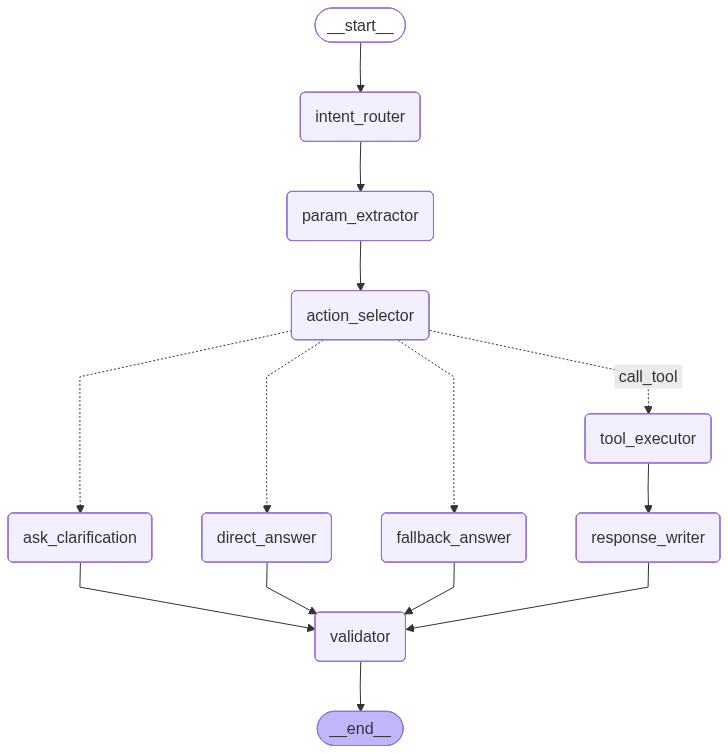

In [ ]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))